In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(org.Hs.eg.db)
library(msigdbr)
library(enrichplot)
library(clusterProfiler)
library(stringr)
library(ggpubr)
library(tidyr)
library(GseaVis)

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:dplyr':

    combine, intersect, setdiff, union


The following objects are masked from 'package:stats'

In [2]:
obj <- readRDS("/opt/data/private/Update/obj_IAV.rds")

In [3]:
Idents(obj) <- "disease"
IAV <- subset(obj,idents = 'IAV')

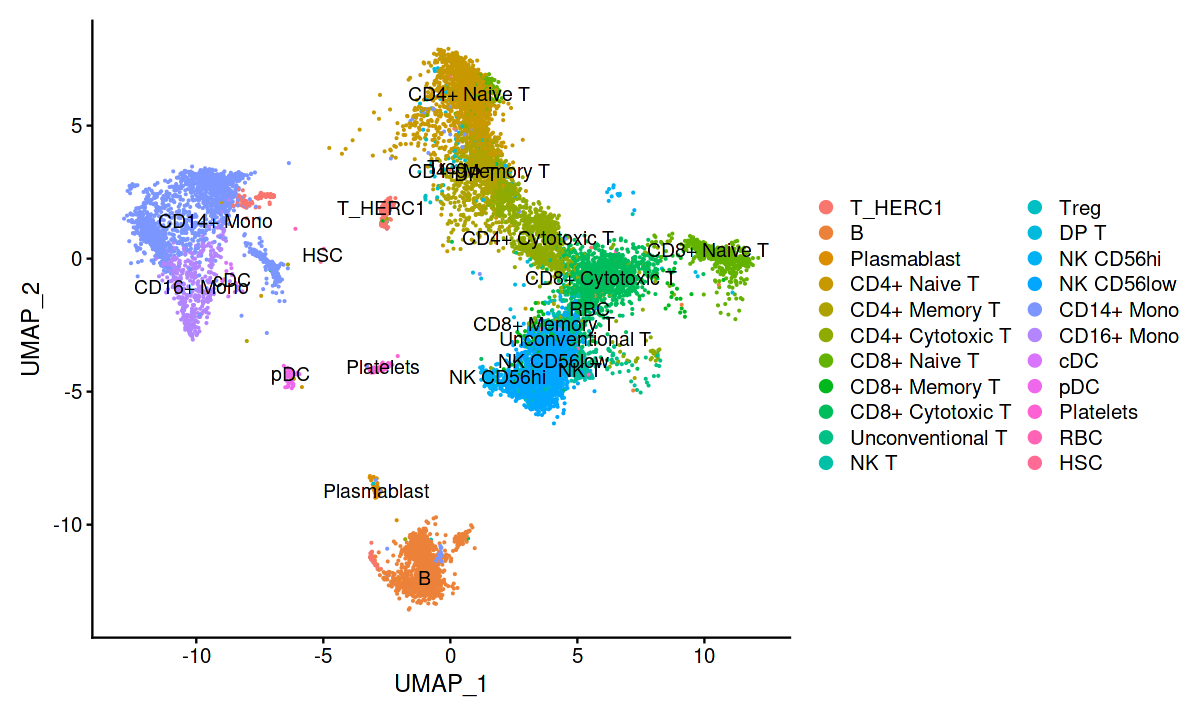

In [4]:
Idents(IAV) <- "celltype"
IAV <- RenameIdents(IAV,'MAIT' = "Unconventional T",'gdT'  = "Unconventional T")
Idents(IAV) <- factor(Idents(IAV), levels = c("T_HERC1","B","Plasmablast","CD4+ Naive T","CD4+ Memory T","CD4+ Cytotoxic T",
                                              "CD8+ Naive T","CD8+ Memory T","CD8+ Cytotoxic T","Unconventional T",
                                              "NK T","Treg","DP T","NK CD56hi","NK CD56low","CD14+ Mono",
                                              "CD16+ Mono","cDC","pDC","Platelets","RBC","HSC"))
options(repr.plot.width = 10, repr.plot.height = 6)
DimPlot(IAV,label = TRUE,raster = FALSE)                                              


In [5]:
IAV_T <- subset(IAV,idents = c('T_HERC1','CD4+ Naive T','CD4+ Memory T','CD8+ Cytotoxic T',
                               'CD8+ Naive T','CD4+ Cytotoxic T','Treg','Unconventional T',
                               'DP T','CD8+ Memory T'))

In [6]:
table(Idents(IAV_T))


         T_HERC1     CD4+ Naive T    CD4+ Memory T CD4+ Cytotoxic T 
             468             2238              796             1202 
    CD8+ Naive T    CD8+ Memory T CD8+ Cytotoxic T Unconventional T 
             864              132             1523              177 
            Treg             DP T 
              50               42 

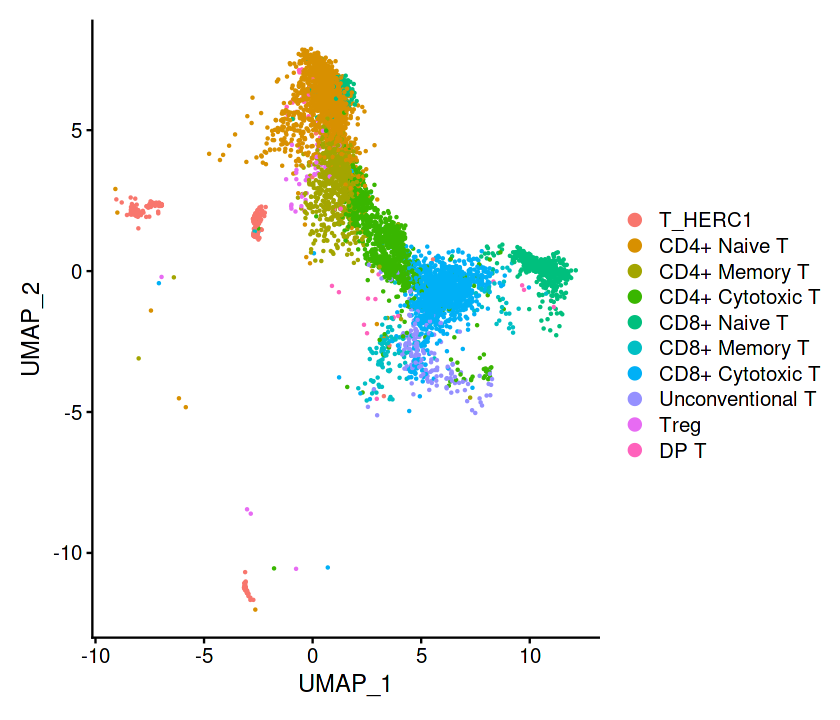

In [7]:
options(repr.plot.width = 7, repr.plot.height = 6)
DimPlot(IAV_T,raster = FALSE)

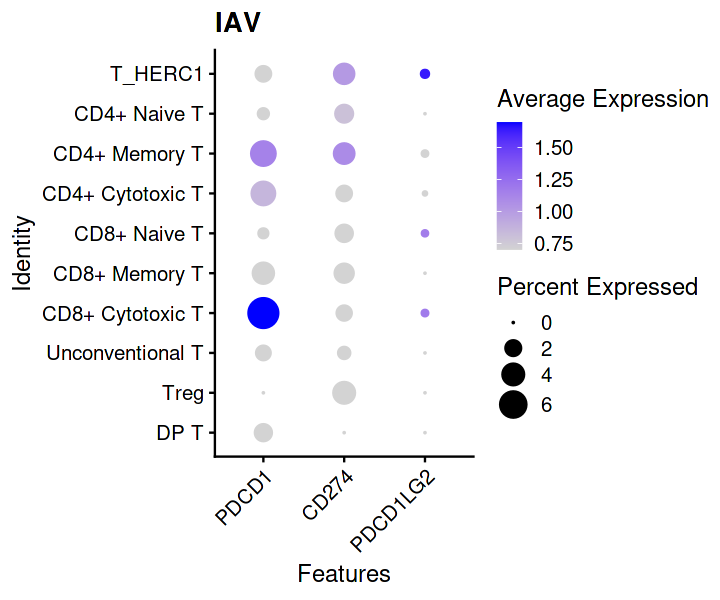

In [9]:
features <- c("PDCD1","CD274","PDCD1LG2")

options(repr.plot.width = 6, repr.plot.height = 5)
p1 <- DotPlot(IAV_T, features = features, dot.scale = 8, scale.by = "size", col.min = 0.7, col.max = 1.7) +
     scale_y_discrete(limits = rev) +
     theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
     labs(title = "IAV")
p1

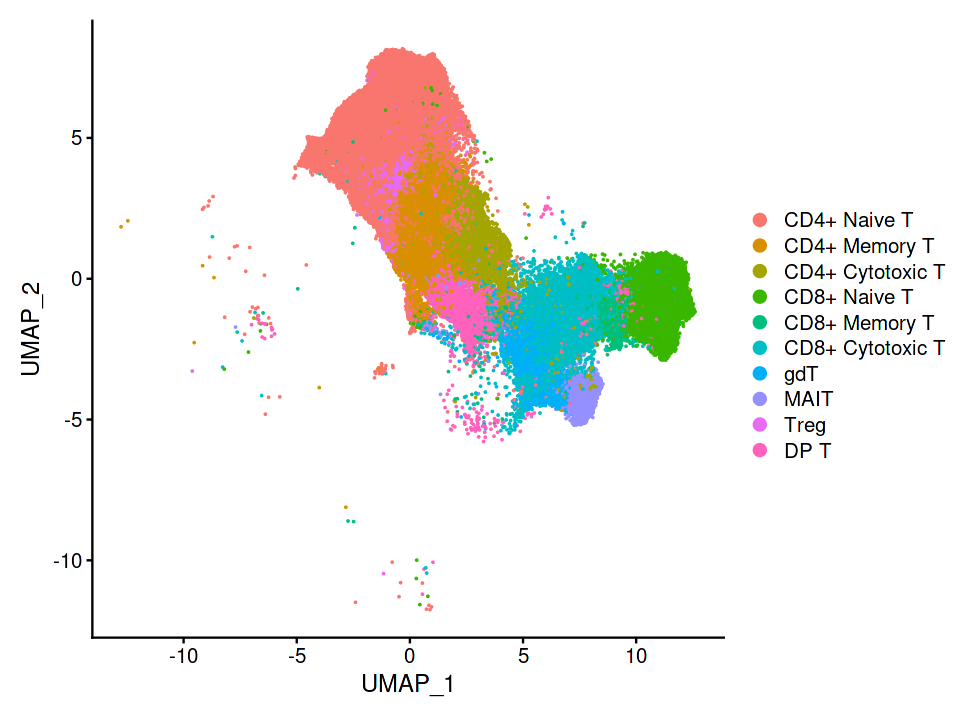

In [12]:
Idents(obj) <- "disease"
HC <- subset(obj,idents = 'HC')
Idents(HC) <- "celltype"
HC_T <- subset(HC,idents = c('CD4+ Naive T','CD4+ Memory T','CD8+ Cytotoxic T',
                             'CD8+ Naive T','CD4+ Cytotoxic T','Treg','MAIT','gdT',
                             'DP T','CD8+ Memory T'))

options(repr.plot.width = 8, repr.plot.height = 6)
DimPlot(HC_T,raster = FALSE)

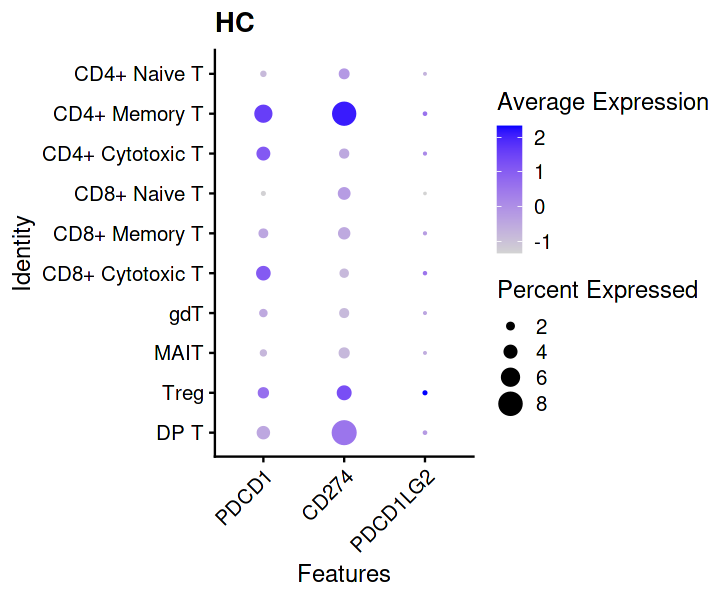

In [13]:
features <- c("PDCD1","CD274","PDCD1LG2")

options(repr.plot.width = 6, repr.plot.height = 5)
p2 <- DotPlot(HC_T, features = features) +
     scale_y_discrete(limits = rev) +
     theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
     labs(title = "HC")
p2

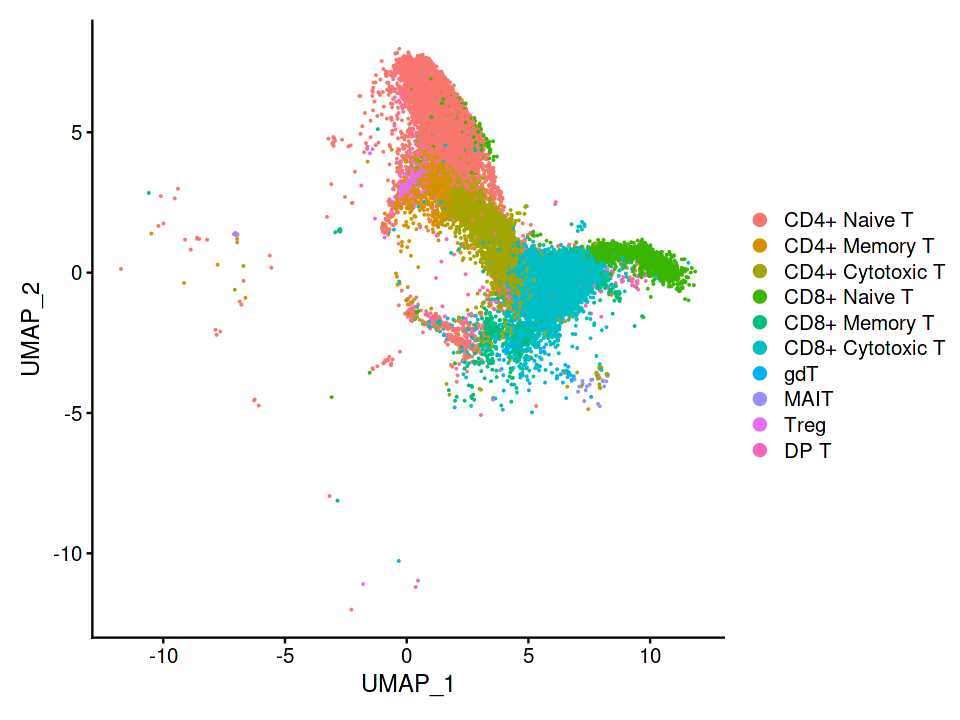

In [15]:
Idents(obj) <- "disease"
COVID <- subset(obj,idents = 'COVID')
Idents(COVID) <- "celltype"
COVID_T <- subset(COVID,idents = c('CD4+ Naive T','CD4+ Memory T','CD8+ Cytotoxic T',
                             'CD8+ Naive T','CD4+ Cytotoxic T','Treg','MAIT','gdT',
                             'DP T','CD8+ Memory T'))

options(repr.plot.width = 8, repr.plot.height = 6)
DimPlot(COVID_T,raster = FALSE)

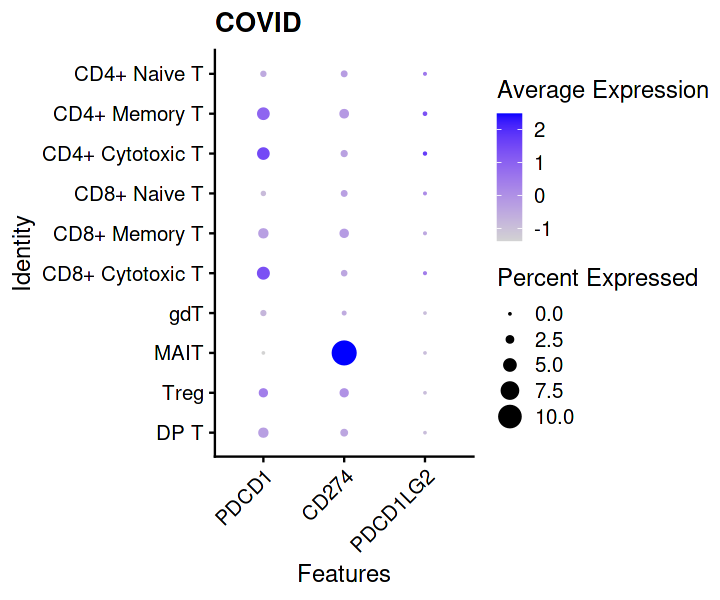

In [16]:
features <- c("PDCD1","CD274","PDCD1LG2")

options(repr.plot.width = 6, repr.plot.height = 5)
p3 <- DotPlot(COVID_T, features = features) +
     scale_y_discrete(limits = rev) +
     theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
     labs(title = "COVID")
p3

In [18]:
T_HERC1.markers <- FindMarkers(IAV_T,ident.1 = "T_HERC1",logfc.threshold = 0)
write.csv(T_HERC1.markers,"/opt/data/private/Update/T_HERC1_IAV.marker_all.csv")

In [19]:
gsea.kegg <- readRDS("/opt/data/private/Update/T_HERC1.GSEAkegg.rds")

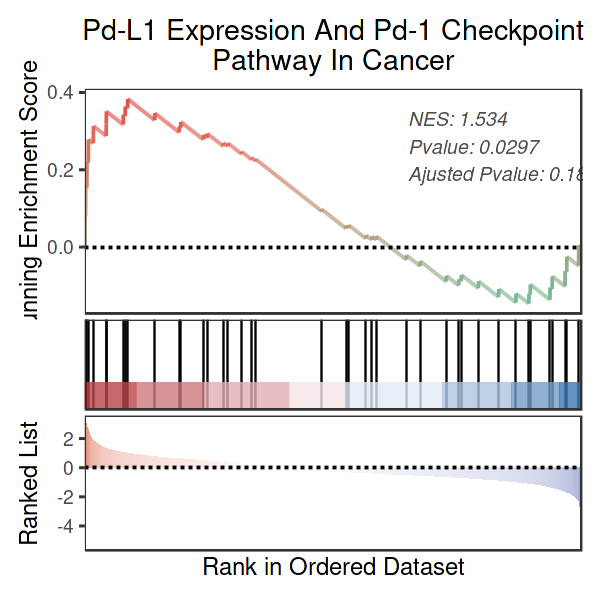

In [21]:
options(repr.plot.width = 5, repr.plot.height = 5)
p4 <- gseaNb(object = gsea.kegg,
       geneSetID = 'hsa05235',
       addPval = T,
       pvalX = 0.65,
       pvalY = 0.7,
       pHjust = 0,
       nesDigit = 4,
       pDigit = 4)
p4

In [23]:
features=c('AKT3','JAK2','MAPK14','PRKCQ','PPP3CA','PPP3CC','PIK3CA','PIK3CD',
           'NFKB1','EML4','HIF1A','PIK3R1','CD247')

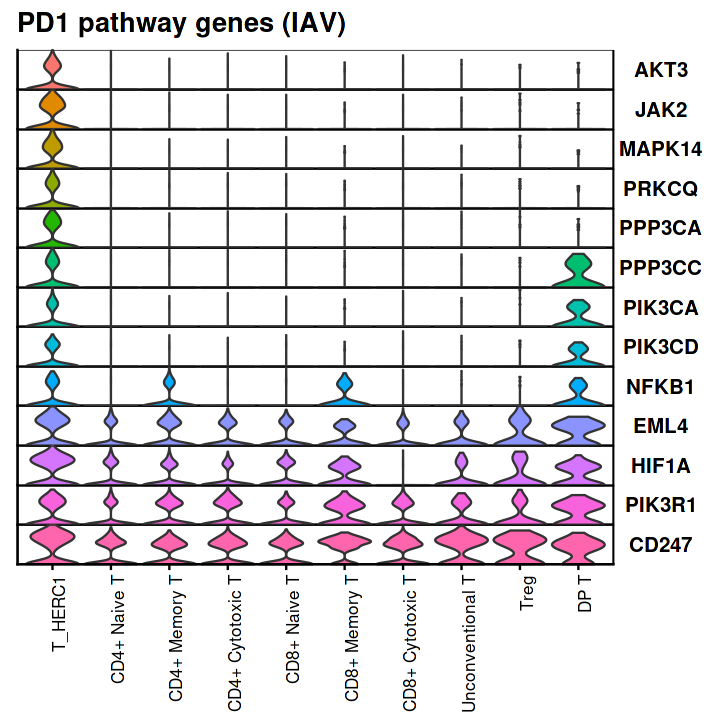

In [25]:
options(repr.plot.width = 6, repr.plot.height = 6)
p5 <- VlnPlot(IAV_T, features, stack = TRUE,flip = TRUE,pt.size=0,add.noise = TRUE, adjust = 1) +
    theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title = element_blank(),
        axis.text.x = element_text(colour = 'black',size = 10,angle = 90),
        legend.position = 'none') +
    labs(title = "PD1 pathway genes (IAV)")
p5